EDA 1: Top & Bottom Performing Hospitals

In [2]:
# Objective:

# To identify the best and worst performing hospitals based on key healthcare measures

# The dataset contains only a single time period i.e. 2022-23 hence this analysis focuses on cross-sectional performance across hospitals.

# Questions that are addresses through this EDA:

# 1- Which hospitals perform the best?
# 2- Which hospitals perform the worst?
# 3- Are there any noticeable patterns across states or hospital types?

In [6]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for better visualization aesthetics
sns.set_theme(style="whitegrid")

In [ ]:
# Loading the clean dataset
df=pd.read_csv('../data/processed/cleaned_master_data.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4480288, 9)


,value,data_period,hospital_name,state,hospital_type,measure_code,measure_name,unit,reported_measure_name
0,108.00,2022-23,Byron Central Hospital,New South Wales,Local Hospital Network,Myh0006,Number Of Elective Surgeries,Surgeries,Urgent Elective Surgery
1,25.00,2022-23,Royal Rehabilitation Hospital,New South Wales,Local Hospital Network,Myh0006,Number Of Elective Surgeries,Surgeries,Laryngectomy
2,75.00,2022-23,Wingham Hospital,New South Wales,Local Hospital Network,Myh0007,Percentage Of Patients Who Waited Longer Than ...,Percent,Curettage And Evacuation Of Uterus
3,1620.00,2022-23,Launceston General Hospital,Tasmania,Local Hospital Network,Myh0007,Percentage Of Patients Who Waited Longer Than ...,Percent,Common Peroneal Nerve Release
4,85.16,2022-23,South West Healthcare [Camperdown],Victoria,Local Hospital Network,Myh0009,Median Waiting Time For Elective Surgery,Days,Procedure For Strabismus (Squint Repair)


In [12]:
print("Unique hospitals:", df['hospital_name'].nunique())
print("Unique measures:", df['measure_name'].nunique())
print('Unique states:', df['state'].nunique())

Unique hospitals: 727
Unique measures: 31
Unique states: 8


In [13]:
# KPI: emergency wait time
# from the dataset, we can see that there are multiple measures related to 
# wait times. For this analysis, we will focus on the 
# "Median Waiting Time For Elective Surgery" as a 
# key performance indicator (KPI) for hospital performance.
key_measure= "Median Waiting Time For Elective Surgery"

df_measure=df[df['measure_name']==key_measure]

print("filtered dataset shape:" , df_measure.shape)
df_measure.head()

filtered dataset shape: (1079473, 9)


,value,data_period,hospital_name,state,hospital_type,measure_code,measure_name,unit,reported_measure_name
4,85.16,2022-23,South West Healthcare [Camperdown],Victoria,Local Hospital Network,Myh0009,Median Waiting Time For Elective Surgery,Days,Procedure For Strabismus (Squint Repair)
7,39.00,2022-23,Wellington Health Service,New South Wales,Local Hospital Network,Myh0009,Median Waiting Time For Elective Surgery,Days,Axillary Node Dissection
8,9.00,2022-23,Caloundra Hospital,Queensland,Local Hospital Network,Myh0009,Median Waiting Time For Elective Surgery,Days,Cerebral Haematoma - Evacuation Of
10,83.36,2022-23,Katherine Hospital,Northern Territory,Local Hospital Network,Myh0009,Median Waiting Time For Elective Surgery,Days,Other Surgery
13,82.00,2022-23,Lorne Community Hospital,Victoria,Local Hospital Network,Myh0009,Median Waiting Time For Elective Surgery,Days,Trabeculectomy


Aggregate Hospital Performance

In [22]:
hospital_performance = (
  df_measure.groupby(['hospital_name', 'state', 'hospital_type'])['value'].mean().reset_index()
)

hoapital_performance=hospital_performance.sort_values(by='value')

hospital_performance.head()



,hospital_name,state,hospital_type,value
0,Adelaide,South Australia,Local Hospital Network,157.634825
1,Adolescent And Young Adult Hospice Manly,New South Wales,Local Hospital Network,177.181396
2,Albany Hospital,Western Australia,Local Hospital Network,278.910809
3,Albury Wodonga Health [Albury Campus],New South Wales,Local Hospital Network,144.261065
4,Albury Wodonga Health [Wodonga Campus],Victoria,Local Hospital Network,217.618851


Top & Bottom 10 Hospitals

In [26]:
top_10_hospitals= hospital_performance.nlargest(10, columns='value')
bottom_10_hospitals= hospital_performance.nsmallest(10, columns='value').sort_values(by='value', ascending=False)

print("Top 10 Hospitals:")
display(top_10_hospitals)
print("Bottom 10 Hospitals:")
display(bottom_10_hospitals)

Top 10 Hospitals:


,hospital_name,state,hospital_type,value
279,Home Hill Hospital,Queensland,Local Hospital Network,318.097117
369,Manilla Hospital,New South Wales,Local Hospital Network,316.824847
451,Normanton Hospital,Queensland,Local Hospital Network,315.249551
330,Kununurra Hospital,Western Australia,Local Hospital Network,312.937840
397,Milton Ulladulla Hospital,New South Wales,Local Hospital Network,311.089345
424,Mungindi Hospital,Queensland,Local Hospital Network,305.818057
484,Pemberton Hospital,Western Australia,Local Hospital Network,303.715294
55,Biggenden Hospital,Queensland,Local Hospital Network,300.648992
700,Whyalla Hospital And Health Services,South Australia,Local Hospital Network,296.673649
256,Gulgong Multi Purpose Service,New South Wales,Local Hospital Network,294.102515


Bottom 10 Hospitals:


,hospital_name,state,hospital_type,value
238,Goodooga Health Service,New South Wales,Local Hospital Network,139.745661
510,Queen Elizabeth Ii Jubilee Hospital,Queensland,Local Hospital Network,137.009588
329,Kununoppin Health Service,Western Australia,Local Hospital Network,136.622880
400,Molong Health Service,New South Wales,Local Hospital Network,136.093827
483,Peel Health Campus,Western Australia,Local Hospital Network,134.759031
222,Gayndah Hospital,Queensland,Local Hospital Network,129.845209
31,Bamaga Hospital,Queensland,Local Hospital Network,127.315085
435,Nannup Hospital,Western Australia,Local Hospital Network,121.157337
687,West Wimmera Health Service [Rupanyup],Victoria,Local Hospital Network,119.564703
152,Coral Tree Family Centre,New South Wales,Local Hospital Network,118.569620


Visualization (Top 10)

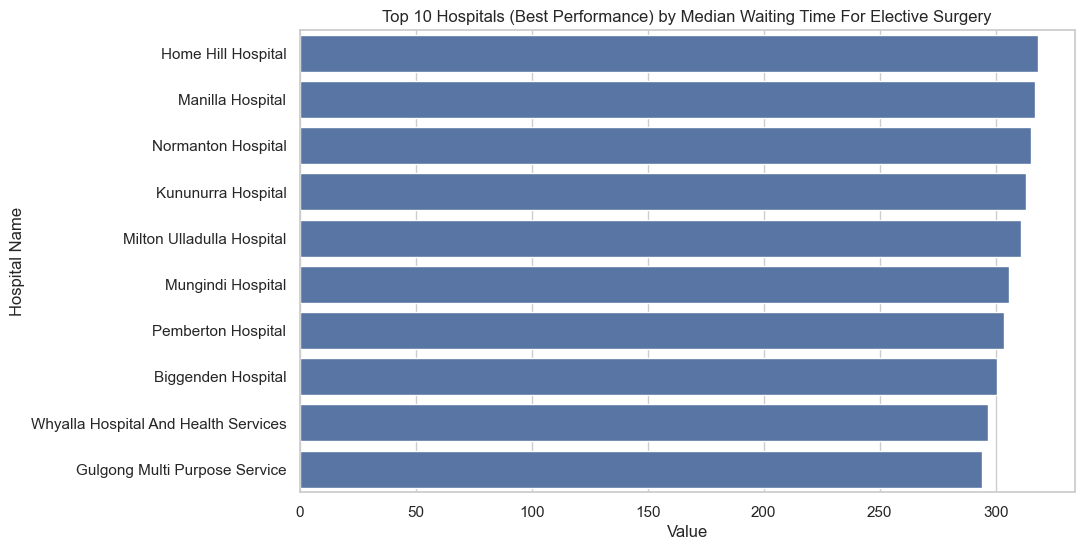

In [28]:
plt.figure(figsize=(10,6))
sns.barplot(
  data=top_10_hospitals,
  x='value',
  y='hospital_name',
)
plt.title(f"Top 10 Hospitals (Best Performance) by {key_measure}")
plt.xlabel("Value")
plt.ylabel("Hospital Name")
plt.show()